# 1. Загрузка данных, EDA

In [2171]:
import pandas as pd
import numpy as np
import seaborn as sns  #visualisation
import matplotlib.pyplot as plt  #visualisation
from sklearn.model_selection import train_test_split
%matplotlib inline
sns.set_theme(color_codes=True)

In [2172]:
df = pd.read_csv('student_lifestyle_100k.csv')
df.head(2)

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False


In [2173]:
# Убираем Student_ID, т.к. он не несёт смысловой нагрузки для обучения модели
df.drop(columns=['Student_ID'], inplace=True)

df.rename(columns={"Age": "age",
                   "Gender": "gender",
                   "Department": "department",
                   "CGPA": "grade",
                   "Sleep_Duration": "sleep_hours",
                   "Study_Hours": "study_hours",
                   "Social_Media_Hours": "social_hours",
                   "Physical_Activity": "physical_minutes_week",
                   "Stress_Level": "stress",
                   "Depression": "depression",
                   }, inplace=True)

print("Пропуски: ", df.isnull().sum().sum())
print("Дубликаты:", df.duplicated().sum())

Пропуски:  0
Дубликаты: 0


,age,gender,department,grade,sleep_hours,study_hours,social_hours,physical_minutes_week,stress,depression
count,100000.000000,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000
unique,NaN,2,5,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,Male,Science,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,NaN,50120,20071,NaN,NaN,NaN,NaN,NaN,NaN,89938
mean,21.009010,NaN,NaN,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660,NaN
std,2.000382,NaN,NaN,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151,NaN
min,18.000000,NaN,NaN,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000,NaN
25%,19.000000,NaN,NaN,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000,NaN
50%,21.000000,NaN,NaN,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000,NaN
75%,23.000000,NaN,NaN,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000,NaN


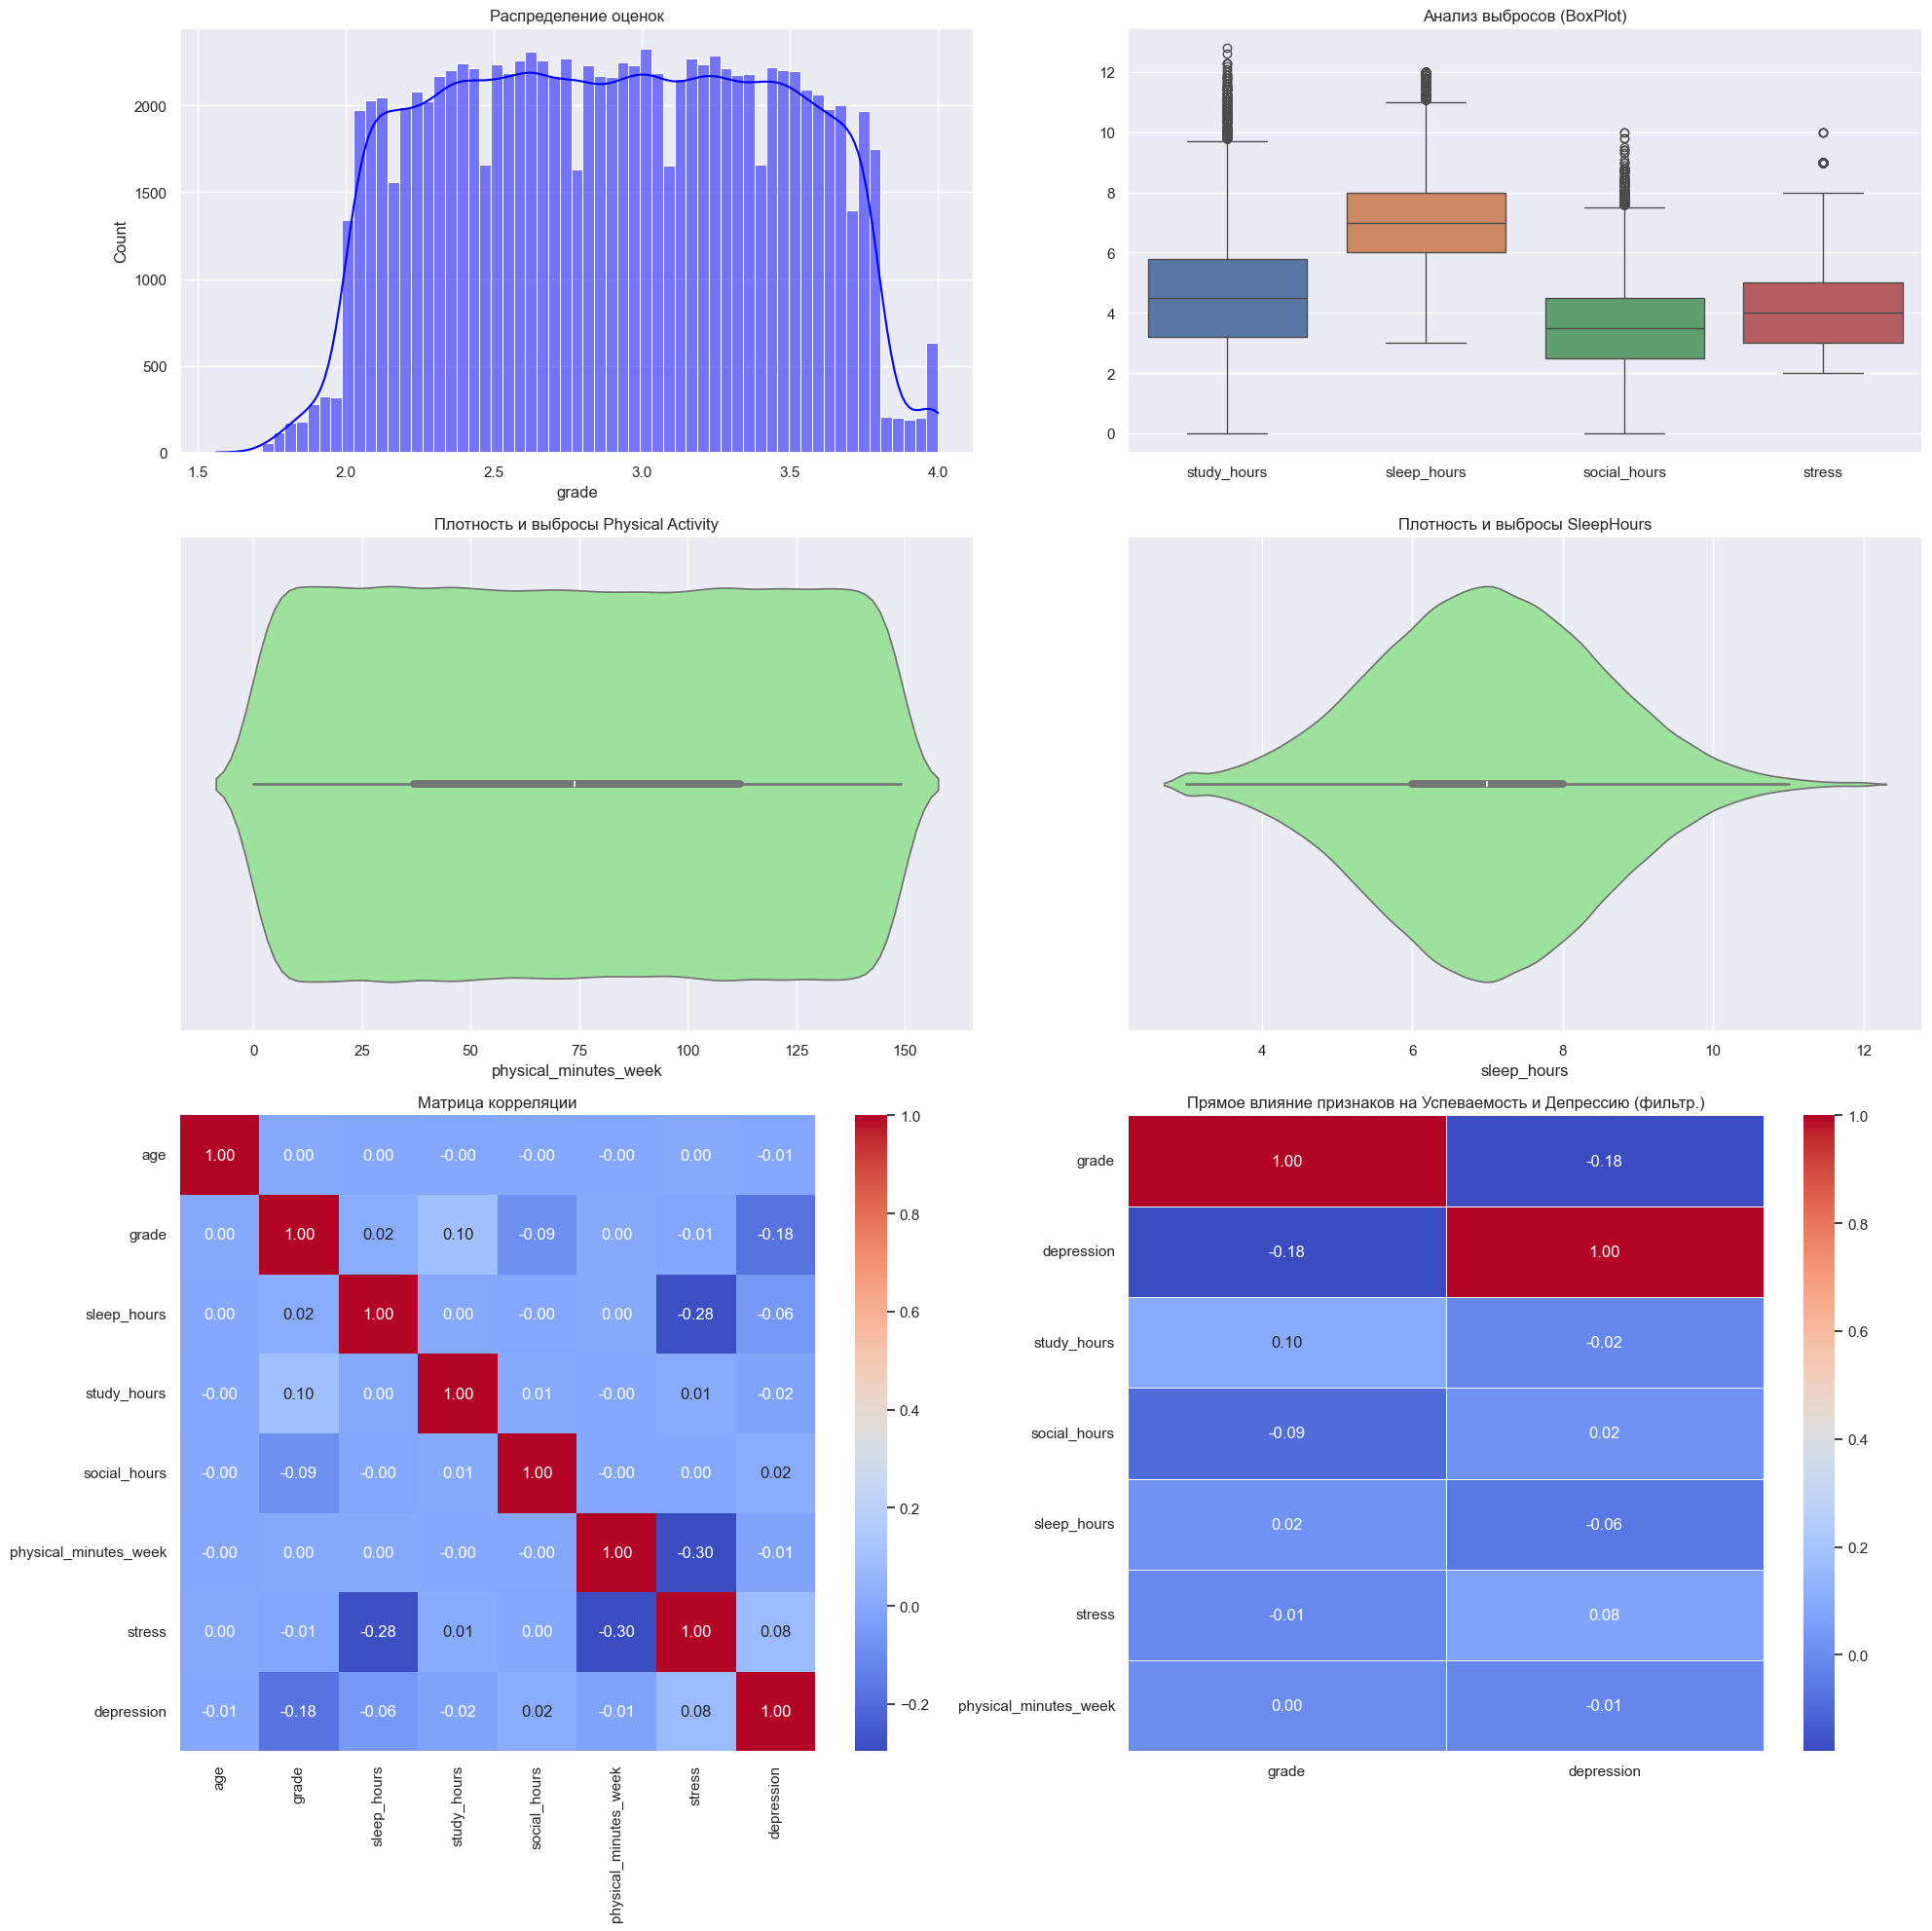

In [2174]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

display(df.describe(include='all'))

fig, axes = plt.subplots(3, 2, figsize=(20, 20),
                         gridspec_kw={'height_ratios': [0.6, 0.7, 0.9], 'width_ratios': [1, 1]})

sns.histplot(df['grade'], kde=True, color='blue', ax=axes[0, 0])
axes[0, 0].set_title('Распределение оценок')

sns.boxplot(data=df[['study_hours', 'sleep_hours', 'social_hours', 'stress']], ax=axes[0, 1])
axes[0, 1].set_title('Анализ выбросов (BoxPlot)')

sns.violinplot(x=df['physical_minutes_week'], color='lightgreen', ax=axes[1, 0])
axes[1, 0].set_title('Плотность и выбросы Physical Activity')

sns.violinplot(x=df['sleep_hours'], color='lightgreen', ax=axes[1, 1])
axes[1, 1].set_title('Плотность и выбросы SleepHours')

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[2, 0])
axes[2, 0].set_title('Матрица корреляции')

# Добавим строковые значения
cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe_encoded_data = ohe.fit_transform(df[cat_cols])
ohe_df = pd.DataFrame(
    ohe_encoded_data,
    columns=ohe.get_feature_names_out(cat_cols),
    index=df.index
)
ohe_df = pd.concat([df.drop(columns=cat_cols), ohe_df], axis=1)

target_corr = ohe_df.corr()[['grade', 'depression']].sort_values(by='grade', ascending=False, key=lambda x: x.abs())
threshold = 0.01
important_features = target_corr[(target_corr['grade'].abs() > threshold) |
                                 (target_corr['depression'].abs() > threshold)]

sns.heatmap(important_features, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=axes[2, 1])
axes[2, 1].set_title('Прямое влияние признаков на Успеваемость и Депрессию (фильтр.)')

plt.tight_layout()
plt.show()

df = ohe_df



### Что видим
- Теоретически "возможно", что у людей больше 24-часов в сутках (см. значения max в таблице)
- `grade` распределено в середине почти равномерно (!!)
- Есть выбросы – нужно убрать (99 перцентиль)
- График плотности `physical_minutes_week` – прямоугольник –> все студенты занимаются по-разному
- Корреляция очень маленькая

### "Прямое влияние признаков на успеваемость и депрессию"
#### - Успеваемость (`grade`):
- Влияет больше всего: `depression`, `study_hours`, `social_hours`
- Не влияет: `age`, `department`, `gender`

#### - Депрессия (`depression`):
- Влияет больше всего: `grade`, `stress` и `sleep_hours`
- Не влияет: `age`, `department`, `gender`

> Отсутствие влияния `age`, `department` и `gender` было выяснено через "Прямое влияние признаков" – однако в таблице отфильтрованны значения, корреляция с которыми <= 1, поэтому их не видно


## 1.1. До-EDA-ние

Удалено людей с "48-часовым" днём: 79


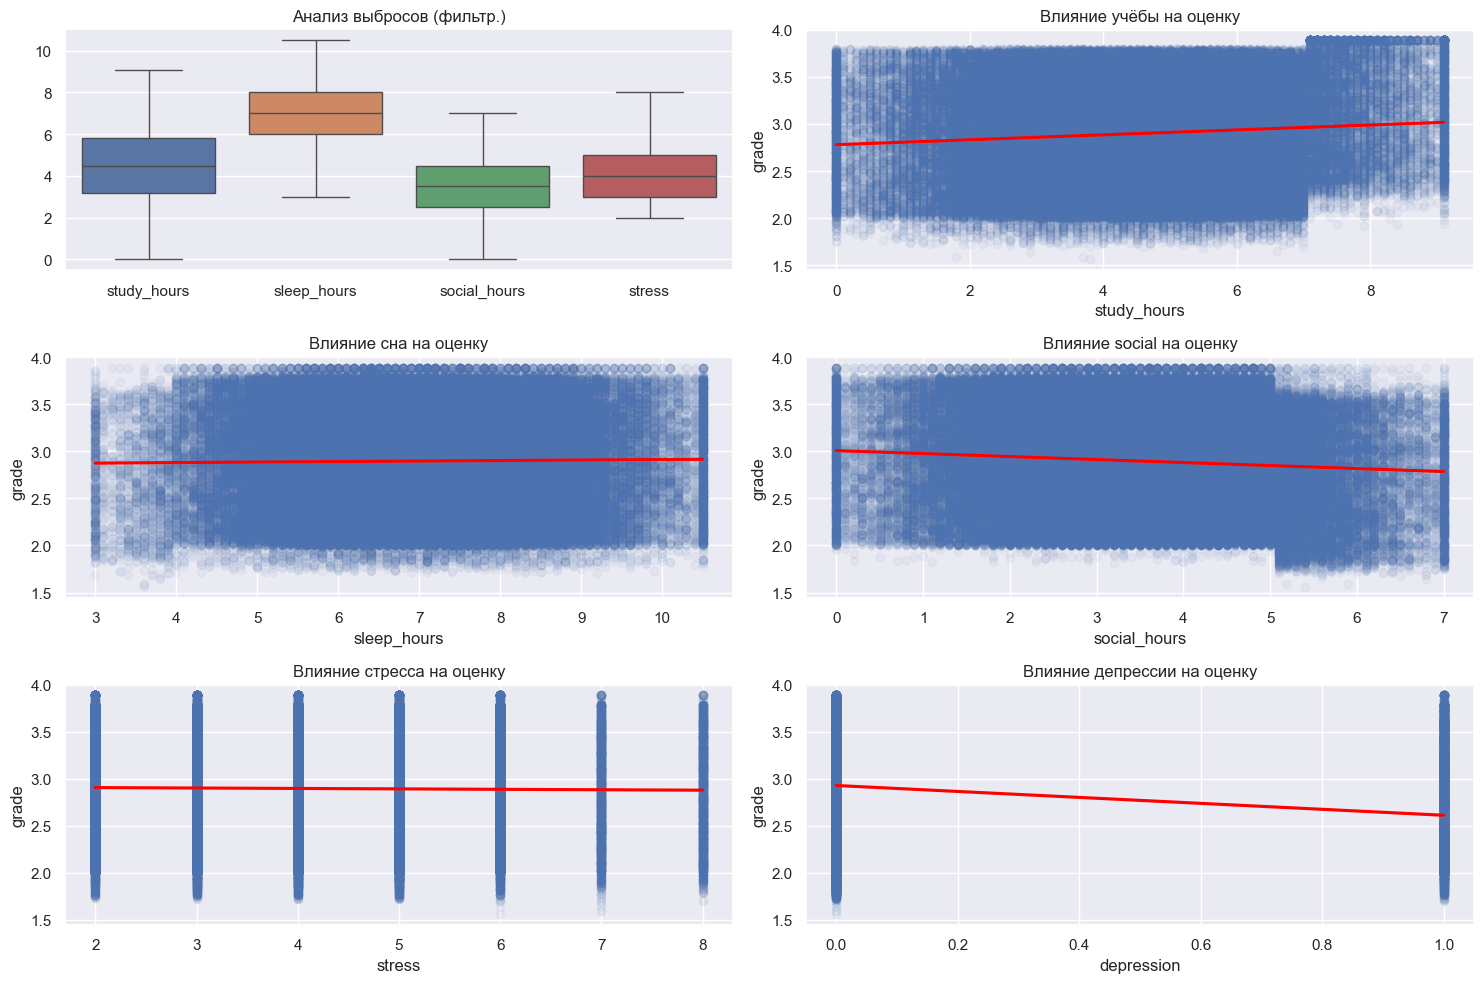

In [2175]:
# Убираеим лишние колонки
to_keep = ['study_hours', 'sleep_hours', 'social_hours', 'stress', 'grade', 'depression', 'physical_minutes_week']
df = df[to_keep]

# Убираем 48-часов в дне
before_filter_48hours_people = df.count()
df = df[df['sleep_hours'] + df['study_hours'] + df['social_hours'] <= 24]
after_filter_48hours_people = df.count()
print(f"Удалено людей с \"48-часовым\" днём: {(before_filter_48hours_people - after_filter_48hours_people).iloc[0]}")

# Убираем выбросы
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    lower = df[col].quantile(0.00)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

rows = 3
fig, axes_root = plt.subplots(rows, 2, figsize=(15, 10))
axes = axes_root.flatten()

sns.boxplot(data=df[['study_hours', 'sleep_hours', 'social_hours', 'stress']], ax=axes[0])
axes[0].set_title('Анализ выбросов (фильтр.)')

xs = {
    'study_hours': "учёбы",
    'sleep_hours': "сна",
    'social_hours': "social",
    'stress': 'стресса',
    'depression': 'депрессии'
}

for i, (col, label) in enumerate(xs.items(), start=1):
    sns.regplot(
        data=df,
        x=col,
        y='grade',
        scatter_kws={'alpha': 0.05},
        line_kws={'color': 'red'},
        ax=axes[i]
    )
    axes[i].set_title(f'Влияние {label} на оценку')

plt.tight_layout()
plt.show()


Низкая корреляция только в другом виде...

#
# 2. Регрессия

Ниже блок кода с функциями – тренировка и метрики ниже

In [2176]:
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, SGDClassifier
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

from sklearn.pipeline import Pipeline


# from practice5
def evaluate_regression(y_true, y_pred, dataset_name, feature, weights, prev_metrics=None, prev_train=None):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    current_metrics = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

    descriptions = {
        'MAE': 'средняя абсолютная ошибка (чем меньше, тем точнее)',
        'RMSE': 'среднеквадратичная ошибка (сильнее штрафует за большие промахи)',
        'R2': 'коэффициент детерминации (чем ближе к 1, тем лучше модель объясняет данные)',
        'MAPE': 'средняя ошибка в процентах (показывает масштаб отклонения)'
    }

    print(f"\n📊 Метрики для {dataset_name}:")

    for key, val in current_metrics.items():
        train_diff_str = ""
        if prev_train and key in prev_train:
            diff_t = val - prev_train[key]
            color_t = "+" if diff_t > 0 else ""
            train_diff_str = f" [{color_t}{diff_t:.4f} train]"

        prev_diff_str = ""
        if prev_metrics and key in prev_metrics:
            diff_p = val - prev_metrics[key]
            color_p = "+" if diff_p > 0 else ""
            prev_diff_str = f" ({color_p}{diff_p:.4f} prev)"

        unit = "%" if key == "MAPE" else ""
        desc = descriptions.get(key, "")
        print(f"  {key}: {val:,.4f}{unit}{train_diff_str}{prev_diff_str}    – {desc}")

    if "test" in dataset_name.lower():
        importance = pd.DataFrame({'feature': feature, 'weight': weights.flatten()})
        importance = importance.sort_values(by='weight', ascending=False, key=lambda x: x.abs())
        print("\n=== ВЛИЯНИЕ ПРИЗНАКОВ (TOP 10) ===")
        print(importance.head(10))

    return current_metrics


def draw_regression(model, x_train, x_test, y_train, y_test, y_train_pred, y_test_pred, feature_names, name,
                    prev_metrics=None):
    # Сначала считаем train, потом test, чтобы в test видеть дельту относительно train
    train_m = evaluate_regression(y_train, y_train_pred, f"{name} (Train)", feature_names, model.coef_)
    test_m = evaluate_regression(y_test, y_test_pred, f"{name} (Test)", feature_names, model.coef_,
                                 prev_metrics=prev_metrics, prev_train=train_m)

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(16, 18))

    ax1 = plt.subplot(3, 2, 1)
    train_sizes, train_scores, val_scores = learning_curve(
        model, x_train, y_train, cv=5, scoring='r2', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10)
    )
    ax1.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='green', label='Train R²')
    ax1.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', color='blue', label='Val R²')
    ax1.set_title('Learning Curve', fontweight='bold')
    ax1.set_xlabel('Размер обучающей выборки', fontsize=10)
    ax1.set_ylabel('R² Score', fontsize=10)
    ax1.legend()

    ax2 = plt.subplot(3, 2, 2)
    ax2.scatter(y_test, y_test_pred, alpha=0.2, color='purple', s=15)
    ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax2.set_title(f'Actual vs Predicted ({name})', fontweight='bold')
    ax2.set_xlabel('Фактическая оценка', fontsize=10)
    ax2.set_ylabel('Предсказанная оценка', fontsize=10)

    ax3 = plt.subplot(3, 2, 3)
    residuals = y_test - y_test_pred
    ax3.scatter(y_test_pred, residuals, alpha=0.2, color='orange', s=15)
    ax3.axhline(y=0, color='red', linestyle='--', lw=2)
    ax3.set_xlabel('Предсказанная оценка', fontsize=10)
    ax3.set_ylabel('Остатки (факт - предсказание)', fontsize=10)
    ax3.set_title('Residual Plot', fontweight='bold')

    ax4 = plt.subplot(3, 2, 4)
    sns.histplot(residuals, bins=50, kde=True, ax=ax4, color='skyblue')
    ax4.set_xlabel('Значение остатка', fontsize=10)
    ax4.set_ylabel('Частота', fontsize=10)
    ax4.set_title('Распределение остатков', fontweight='bold')

    ax5 = plt.subplot(3, 2, 5)
    coefs = pd.DataFrame({'feature': feature_names, 'coef': model.coef_})
    coefs = coefs.sort_values(by='coef', key=abs, ascending=False).head(15)
    colors = ['green' if c > 0 else 'red' for c in coefs['coef']]
    ax5.barh(coefs['feature'], coefs['coef'], color=colors)
    ax5.invert_yaxis()
    ax5.set_xlabel('Значение коэффициента', fontsize=10)
    ax5.set_title('Топ-15 важных признаков', fontweight='bold')

    ax6 = plt.subplot(3, 2, 6)
    m_keys = ['R2', 'MAE', 'RMSE']
    x_pos = np.arange(len(m_keys))
    ax6.bar(x_pos - 0.2, [train_m[k] for k in m_keys], 0.4, label='Train', color='steelblue')
    ax6.bar(x_pos + 0.2, [test_m[k] for k in m_keys], 0.4, label='Test', color='coral')
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels(m_keys)
    ax6.set_ylabel('Значение', fontsize=10)
    ax6.set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
    ax6.legend()

    plt.tight_layout()
    plt.show()
    return test_m


def regression_metrics(x, y, name, use_poly=False, prev_metrics=None):
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42, shuffle=True
    )

    print(f"Размер обучающей выборки: {x_train.shape[0]}")
    print(f"Размер тестовой выборки: {x_test.shape[0]}")

    steps = []
    if use_poly:
        steps.append(('poly', PolynomialFeatures(degree=2, include_bias=False)))
    steps.append(('scaler', StandardScaler()))
    steps.append(('model', LinearRegression()))

    pipeline = Pipeline(steps)
    pipeline.fit(x_train, y_train)

    if use_poly:
        feature_names = pipeline.named_steps['poly'].get_feature_names_out(x.columns)
    else:
        feature_names = x.columns

    # Трансформация для всех шагов: чтобы корректно работал Learning Curve и веса, нам нужны отмасштабированные данные
    preprocessor = pipeline[:-1]
    x_train_transformed = preprocessor.transform(x_train)
    x_test_transformed = preprocessor.transform(x_test)

    y_train_pred = pipeline.predict(x_train)
    y_test_pred = pipeline.predict(x_test)

    metrics = draw_regression(
        model=pipeline.named_steps['model'],
        x_train=x_train_transformed,
        x_test=x_test_transformed,
        y_train=y_train,
        y_test=y_test,
        y_train_pred=y_train_pred,
        y_test_pred=y_test_pred,
        feature_names=feature_names,
        name=name,
        prev_metrics=prev_metrics
    )

    return metrics


## 2.1. Сырое (без своих фич)

Размер обучающей выборки: 79936
Размер тестовой выборки: 19985

📊 Метрики для Linear Regression (without features) (Train):
  MAE: 0.4439    – средняя абсолютная ошибка (чем меньше, тем точнее)
  RMSE: 0.5180    – среднеквадратичная ошибка (сильнее штрафует за большие промахи)
  R2: 0.0485    – коэффициент детерминации (чем ближе к 1, тем лучше модель объясняет данные)
  MAPE: 16.1365%    – средняя ошибка в процентах (показывает масштаб отклонения)

📊 Метрики для Linear Regression (without features) (Test):
  MAE: 0.4423 [-0.0016 train]    – средняя абсолютная ошибка (чем меньше, тем точнее)
  RMSE: 0.5164 [-0.0016 train]    – среднеквадратичная ошибка (сильнее штрафует за большие промахи)
  R2: 0.0466 [-0.0019 train]    – коэффициент детерминации (чем ближе к 1, тем лучше модель объясняет данные)
  MAPE: 16.0208% [-0.1158 train]    – средняя ошибка в процентах (показывает масштаб отклонения)

=== ВЛИЯНИЕ ПРИЗНАКОВ (TOP 10) ===
                 feature    weight
4             depressio

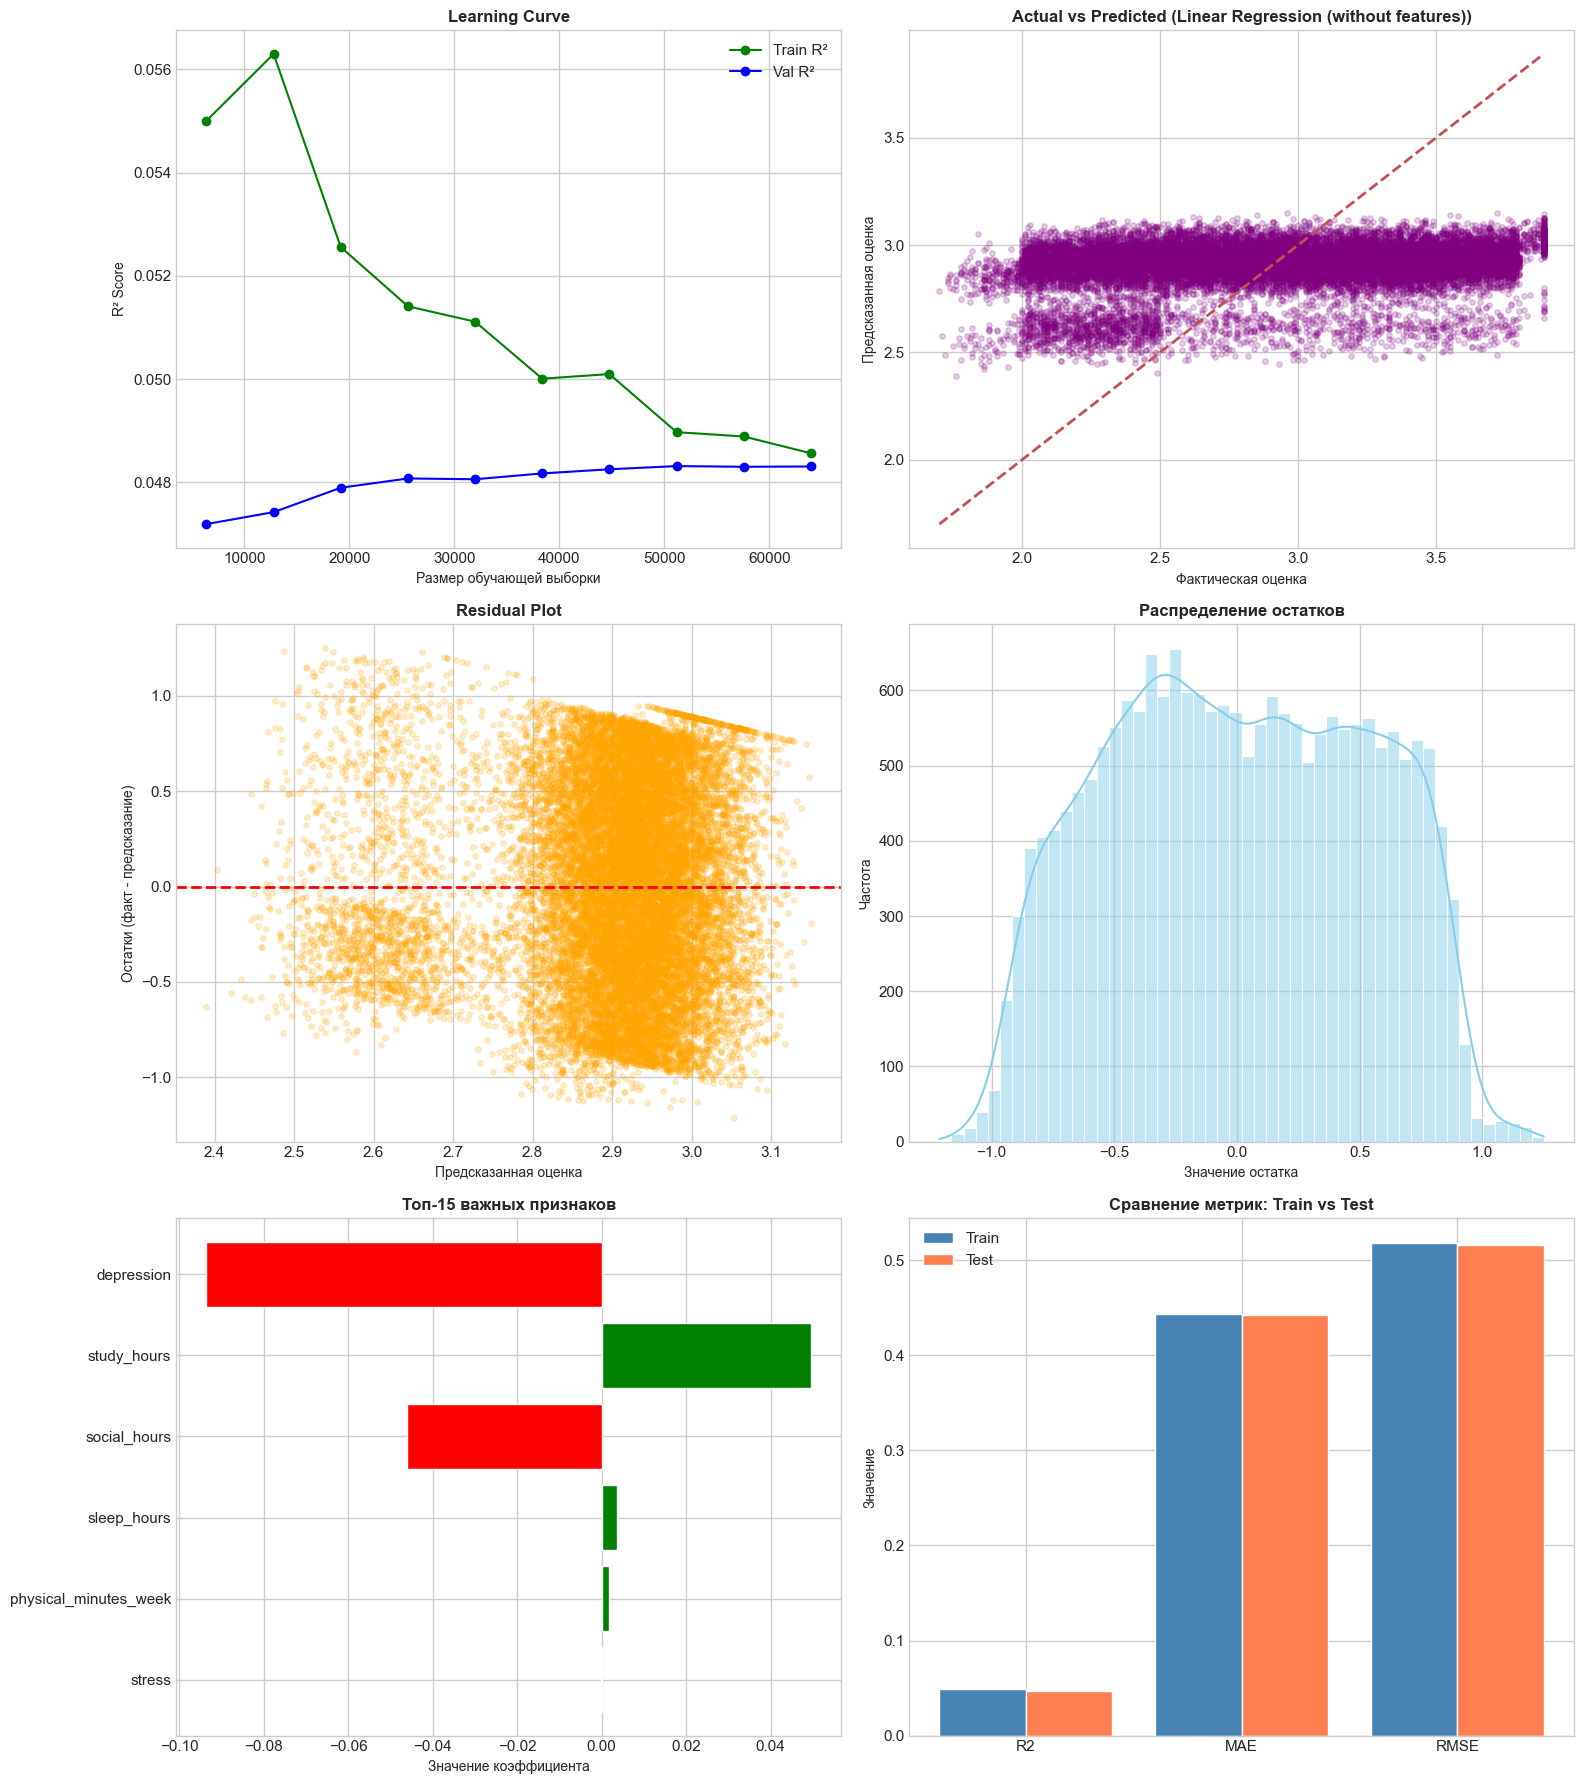

In [2177]:
x_raw_reg = df.drop(columns=['grade'])
y_raw_reg = df['grade']

raw_metrics = regression_metrics(x_raw_reg, y_raw_reg, "Linear Regression (without features)", use_poly=False)

Это была работа с сырыми данными (чтобы потом можно было сравнить с feature engineering), но уже сейчас видно, что модель страдает от недообучения (чуть лучше, чем если бы мы просто всегда предсказывали среднее значение).

## 2.2. С доп признаками (Feature Engineering)

Размер обучающей выборки: 79936
Размер тестовой выборки: 19985

📊 Метрики для Linear Regression (with features) (Train):
  MAE: 0.4409    – средняя абсолютная ошибка (чем меньше, тем точнее)
  RMSE: 0.5137    – среднеквадратичная ошибка (сильнее штрафует за большие промахи)
  R2: 0.0644    – коэффициент детерминации (чем ближе к 1, тем лучше модель объясняет данные)
  MAPE: 16.0152%    – средняя ошибка в процентах (показывает масштаб отклонения)

📊 Метрики для Linear Regression (with features) (Test):
  MAE: 0.4401 [-0.0008 train] (-0.0022 prev)    – средняя абсолютная ошибка (чем меньше, тем точнее)
  RMSE: 0.5131 [-0.0006 train] (-0.0033 prev)    – среднеквадратичная ошибка (сильнее штрафует за большие промахи)
  R2: 0.0587 [-0.0057 train] (+0.0121 prev)    – коэффициент детерминации (чем ближе к 1, тем лучше модель объясняет данные)
  MAPE: 15.9296% [-0.0857 train] (-0.0912 prev)    – средняя ошибка в процентах (показывает масштаб отклонения)

=== ВЛИЯНИЕ ПРИЗНАКОВ (TOP 10) ===
    

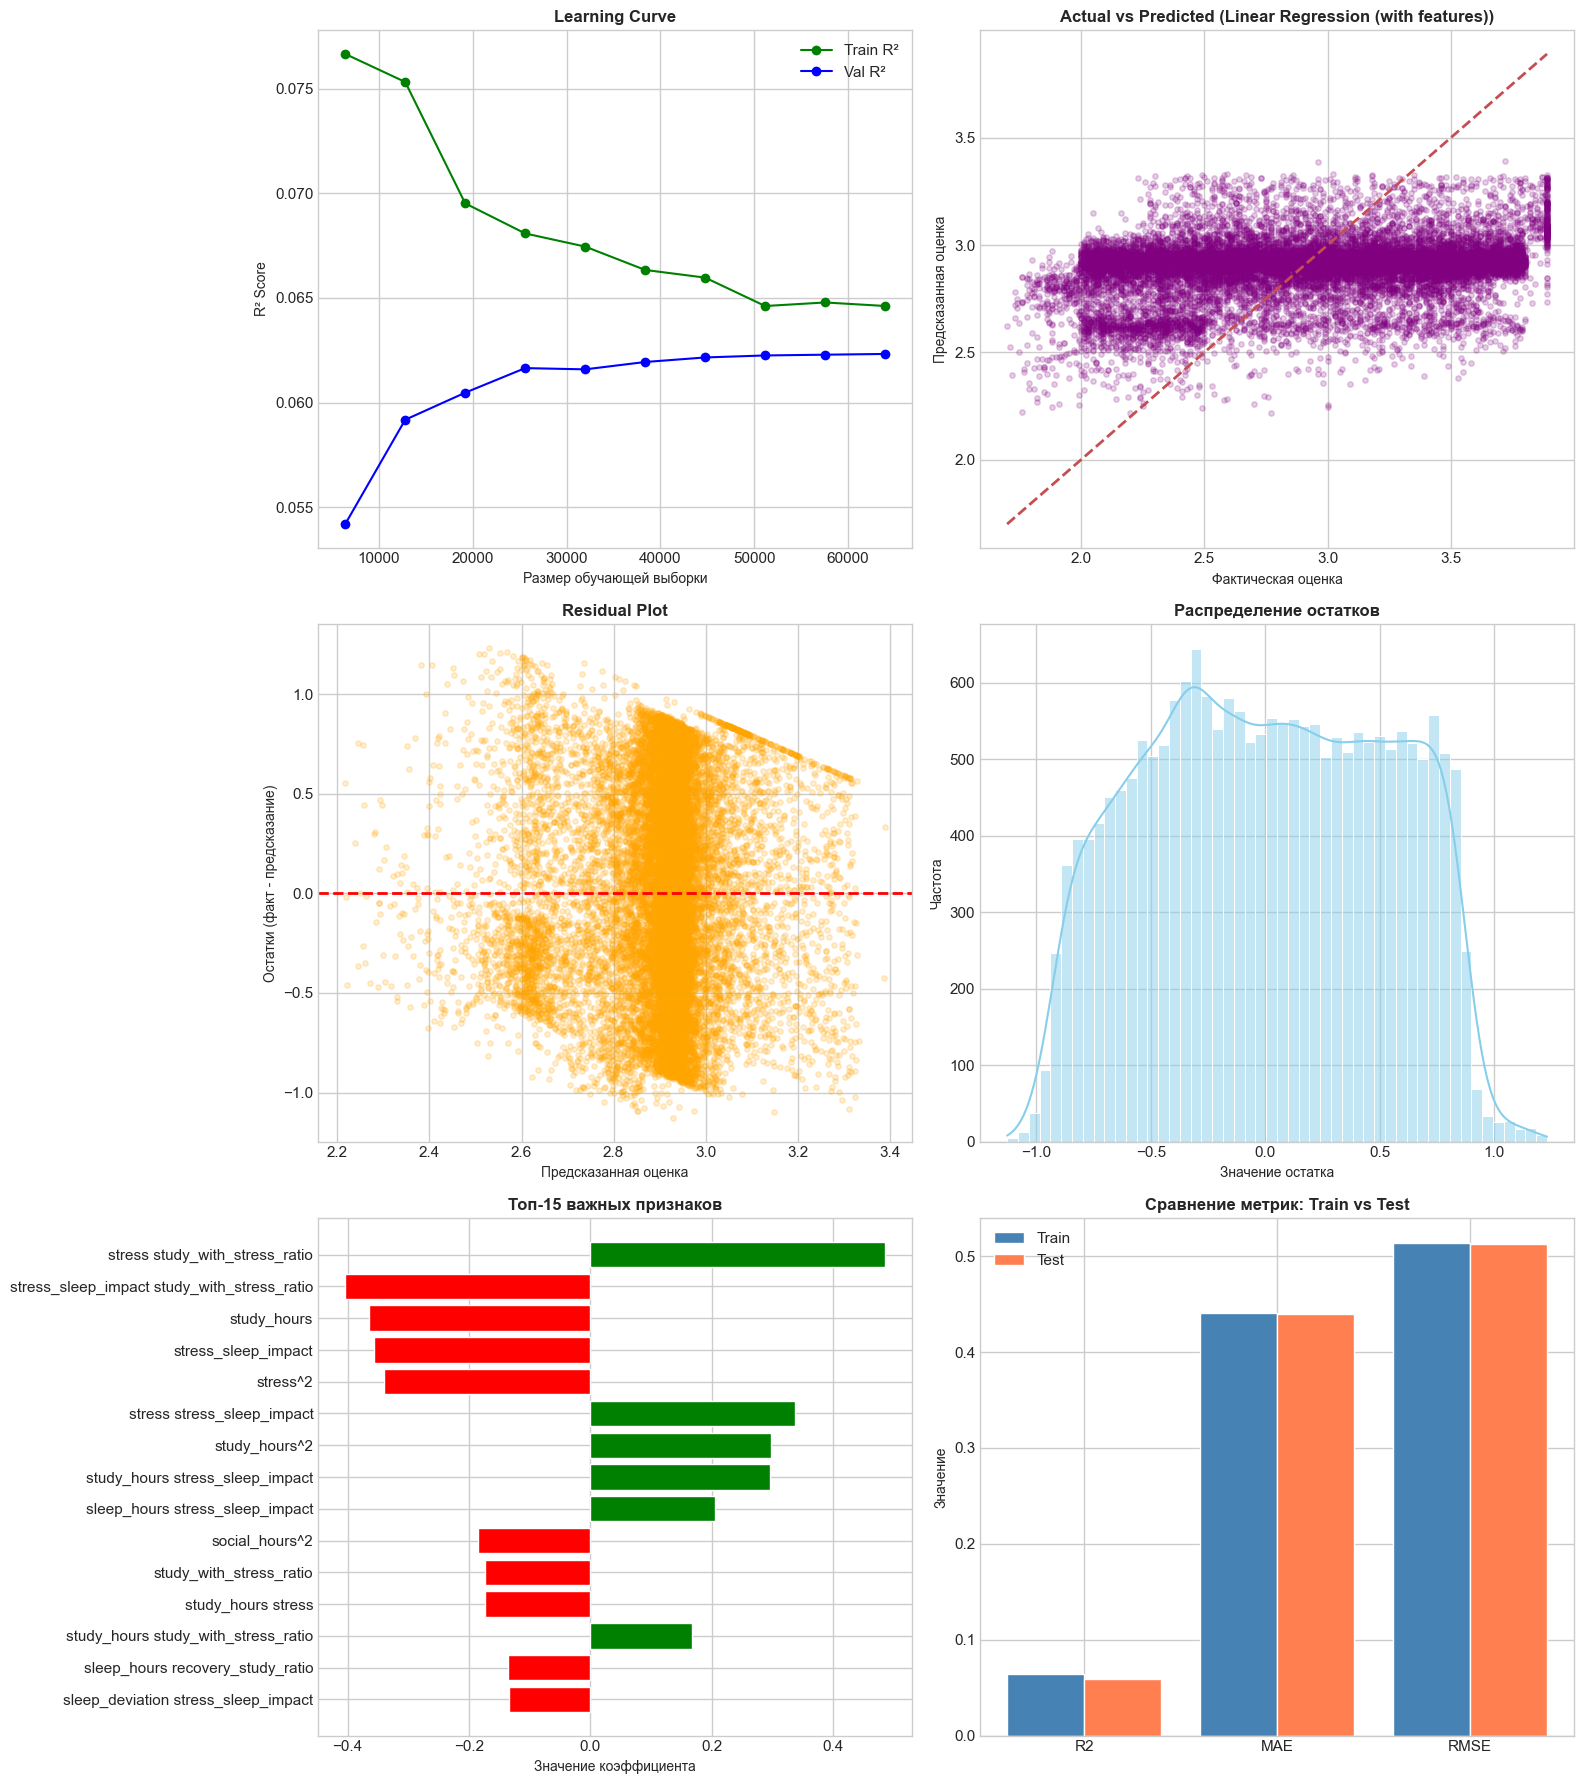

In [2178]:
def add_custom_features(x):
    x['sleep_deviation'] = (x['sleep_hours'] - 7).abs()  # отклонение от нормы сна (7 – база)
    x['stress_sleep_impact'] = x['stress'] / (x['sleep_hours'] + 1)  # индекс выгорания
    x['study_with_stress_ratio'] = x['study_hours'] * x['stress']  # учёба под давлением
    x['recovery_social_ratio'] = x['sleep_hours'] / (x['social_hours'] + 1)  # отдых от social media
    x['recovery_study_ratio'] = x['sleep_hours'] / (x['study_hours'] + 1)  # отдых от учёбы


x_feat_reg = df.drop(columns=['grade'])
y_feat_reg = df['grade']

add_custom_features(x_feat_reg)

feat_metrics = regression_metrics(x_feat_reg, y_feat_reg, "Linear Regression (with features)", prev_metrics=raw_metrics,
                                  use_poly=True)


## Что мы имеем?
Проведение Feature Engineering (создание бизнес-метрик выгорания, баланса учебы/отдыха) и добавление полиномиальных взаимодействий позволило улучшить метрику R2 на ~25%. Анализ весов показал высокую важность комбинированных факторов стресса, сна и учебы. Однако, текущая модель (Linear Regression) объясняет менее 6% дисперсии, сохраняя тенденцию к предсказанию средних значений.


> Датасет плох?

#
# 3. Классификация

In [2179]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, \
    roc_curve

should_print_weights = True


def evaluate_classification(y_true, y_pred, y_proba, dataset_name, feature, weights, prev_metrics=None,
                            prev_train=None):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_true, y_proba) if y_proba is not None else 0

    current_metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1, 'AUC-ROC': auc_roc}

    descriptions = {
        'Accuracy': 'доля правильных ответов (общая точность)',
        'Precision': 'точность (способность отличать этот класс от других)',
        'Recall': 'полнота (способность находить все объекты этого класса)',
        'F1': 'гармоническое среднее между точностью и полнотой',
        'AUC-ROC': 'качество разделения классов моделью (чем выше, тем лучше)'
    }

    print(f"\n📊 Метрики классификации для {dataset_name}:")

    for key, val in current_metrics.items():
        train_diff_str = ""
        if prev_train and key in prev_train:
            diff_t = val - prev_train[key]
            color_t = "+" if diff_t > 0 else ""
            train_diff_str = f" [{color_t}{diff_t:.4f} train]"

        prev_diff_str = ""
        if prev_metrics and key in prev_metrics:
            diff_p = val - prev_metrics[key]
            color_p = "+" if diff_p > 0 else ""
            prev_diff_str = f" ({color_p}{diff_p:.4f} prev)"

        desc = descriptions.get(key, "")
        print(f"  {key:9}: {val:.4f}{train_diff_str}{prev_diff_str}    – {desc}")

    if "test" in dataset_name.lower() and should_print_weights:
        weights_df = pd.DataFrame({'feature': feature, 'weight': weights.flatten()})
        weights_df = weights_df.sort_values(by='weight', ascending=False, key=lambda x: x.abs())

        print(f"\n📈 Топ-5 признаков, УВЕЛИЧИВАЮЩИХ вероятность депрессии")
        top_positive = weights_df[weights_df['weight'] > 0].head(5)
        for _, row in top_positive.iterrows():
            print(f"  + {row['feature']}: {row['weight']:.4f}")

        print(f"\n📉 Топ-5 признаков, УМЕНЬШАЮЩИХ вероятность депрессии")
        top_negative = weights_df[weights_df['weight'] < 0].tail(5)
        for _, row in top_negative.iterrows():
            print(f"  - {row['feature']}: {row['weight']:.4f}")

    return current_metrics


def draw_classification_results(model, x_train, y_train, y_test, y_pred, y_proba, feature_names, name, train_m, test_m):
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(16, 18))

    ax1 = plt.subplot(3, 2, 1)
    train_sizes, train_scores, val_scores = learning_curve(
        model, x_train, y_train, cv=5, scoring='f1', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10)
    )
    ax1.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='green', label='Train F1')
    ax1.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', color='blue', label='Val F1')
    ax1.set_title('Learning Curve (F1-Score)', fontweight='bold')
    ax1.set_xlabel('Размер обучающей выборки', fontsize=10)
    ax1.set_ylabel('F1 Score', fontsize=10)
    ax1.legend()

    ax2 = plt.subplot(3, 2, 2)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False)
    ax2.set_xlabel('Предсказанный класс', fontsize=10)
    ax2.set_ylabel('Фактический класс', fontsize=10)
    ax2.set_title(f'Confusion Matrix ({name})', fontweight='bold')

    ax3 = plt.subplot(3, 2, 3)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {test_m["AUC-ROC"]:.3f})')
    ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    ax3.set_xlim(0.0, 1.0)
    ax3.set_ylim(0.0, 1.05)
    ax3.set_xlabel('False Positive Rate', fontsize=10)
    ax3.set_ylabel('True Positive Rate', fontsize=10)
    ax3.set_title('ROC Curve', fontweight='bold')
    ax3.legend(loc="lower right")

    ax4 = plt.subplot(3, 2, 4)
    sns.histplot(y_proba, bins=50, kde=True, ax=ax4, color='skyblue')
    ax4.axvline(x=0.5, color='red', linestyle='--', lw=2, label='Порог решения (0.5)')
    ax4.set_xlabel('Предсказанная вероятность (Депрессия)', fontsize=10)
    ax4.set_ylabel('Частота', fontsize=10)
    ax4.set_title('Распределение вероятностей', fontweight='bold')
    ax4.legend()

    ax5 = plt.subplot(3, 2, 5)
    coefs = pd.DataFrame({'feature': feature_names, 'coef': model.coef_.flatten()})
    coefs = coefs.sort_values(by='coef', key=abs, ascending=False).head(15)
    colors = ['green' if c > 0 else 'red' for c in coefs['coef']]
    ax5.barh(coefs['feature'], coefs['coef'], color=colors)
    ax5.invert_yaxis()  # чтобы самый важный был сверху
    ax5.set_xlabel('Значение коэффициента', fontsize=10)
    ax5.set_title('Топ-15 важных признаков', fontweight='bold')

    ax6 = plt.subplot(3, 2, 6)
    m_keys = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
    x_pos = np.arange(len(m_keys))
    ax6.bar(x_pos - 0.2, [train_m[k] for k in m_keys], 0.4, label='Train', color='steelblue')
    ax6.bar(x_pos + 0.2, [test_m[k] for k in m_keys], 0.4, label='Test', color='coral')
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels(m_keys)
    ax6.set_ylabel('Значение', fontsize=10)
    ax6.set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
    ax6.set_ylim(0, 1.05)
    ax6.legend()

    plt.tight_layout()
    plt.show()


def classification_task(x, y, name, use_poly=False, prev_metrics=None, thrshld=0.5, draw_results=True):
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
    )

    steps = []
    if use_poly:
        steps.append(('poly', PolynomialFeatures(degree=2, include_bias=False)))
    steps.append(('scaler', StandardScaler()))
    steps.append(('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)))

    pipeline = Pipeline(steps)
    pipeline.fit(x_train, y_train)

    if use_poly:
        feature_names = pipeline.named_steps['poly'].get_feature_names_out(x.columns)
    else:
        feature_names = x.columns

    y_train_proba = pipeline.predict_proba(x_train)[:, 1]
    y_train_pred = (y_train_proba >= thrshld).astype(int)

    y_test_proba = pipeline.predict_proba(x_test)[:, 1]
    y_test_pred = (y_test_proba >= thrshld).astype(int)

    model = pipeline.named_steps['model']
    preprocessor = pipeline[:-1]
    x_train_transformed = preprocessor.transform(x_train)

    train_m = evaluate_classification(
        y_train, y_train_pred, y_train_proba, f"{name} (Train)",
        feature_names, model.coef_
    )

    test_m = evaluate_classification(
        y_test, y_test_pred, y_test_proba, f"{name} (Test)",
        feature_names, model.coef_, prev_metrics, train_m
    )

    if draw_results:
        draw_classification_results(
            model, x_train_transformed, y_train, y_test,
            y_test_pred, y_test_proba, feature_names, name, train_m, test_m
        )

    return test_m

In [2180]:
x_class = df.drop(columns=['depression'])
y_class = df['depression']

print("\n=== ТЕСТ БЕЗ FEATURES ===")

base_class_metrics = classification_task(x_class, y_class, "LogReg Raw", use_poly=False, thrshld=0.45,
                                         draw_results=False)


=== ТЕСТ БЕЗ FEATURES ===

📊 Метрики классификации для LogReg Raw (Train):
  Accuracy : 0.5369    – доля правильных ответов (общая точность)
  Precision: 0.1467    – точность (способность отличать этот класс от других)
  Recall   : 0.7479    – полнота (способность находить все объекты этого класса)
  F1       : 0.2453    – гармоническое среднее между точностью и полнотой
  AUC-ROC  : 0.6852    – качество разделения классов моделью (чем выше, тем лучше)

📊 Метрики классификации для LogReg Raw (Test):
  Accuracy : 0.5360 [-0.0009 train]    – доля правильных ответов (общая точность)
  Precision: 0.1468 [+0.0001 train]    – точность (способность отличать этот класс от других)
  Recall   : 0.7504 [+0.0024 train]    – полнота (способность находить все объекты этого класса)
  F1       : 0.2455 [+0.0002 train]    – гармоническое среднее между точностью и полнотой
  AUC-ROC  : 0.6868 [+0.0016 train]    – качество разделения классов моделью (чем выше, тем лучше)

📈 Топ-5 признаков, УВЕЛИЧИВАЮЩИ


=== ТЕСТ С FEATURES ===

📊 Метрики классификации для LogReg (with features) (Train):
  Accuracy : 0.5476    – доля правильных ответов (общая точность)
  Precision: 0.1499    – точность (способность отличать этот класс от других)
  Recall   : 0.7478    – полнота (способность находить все объекты этого класса)
  F1       : 0.2497    – гармоническое среднее между точностью и полнотой
  AUC-ROC  : 0.6928    – качество разделения классов моделью (чем выше, тем лучше)

📊 Метрики классификации для LogReg (with features) (Test):
  Accuracy : 0.5440 [-0.0036 train] (+0.0080 prev)    – доля правильных ответов (общая точность)
  Precision: 0.1486 [-0.0012 train] (+0.0018 prev)    – точность (способность отличать этот класс от других)
  Recall   : 0.7469 [-0.0009 train] (-0.0035 prev)    – полнота (способность находить все объекты этого класса)
  F1       : 0.2479 [-0.0018 train] (+0.0024 prev)    – гармоническое среднее между точностью и полнотой
  AUC-ROC  : 0.6921 [-0.0007 train] (+0.0053 prev

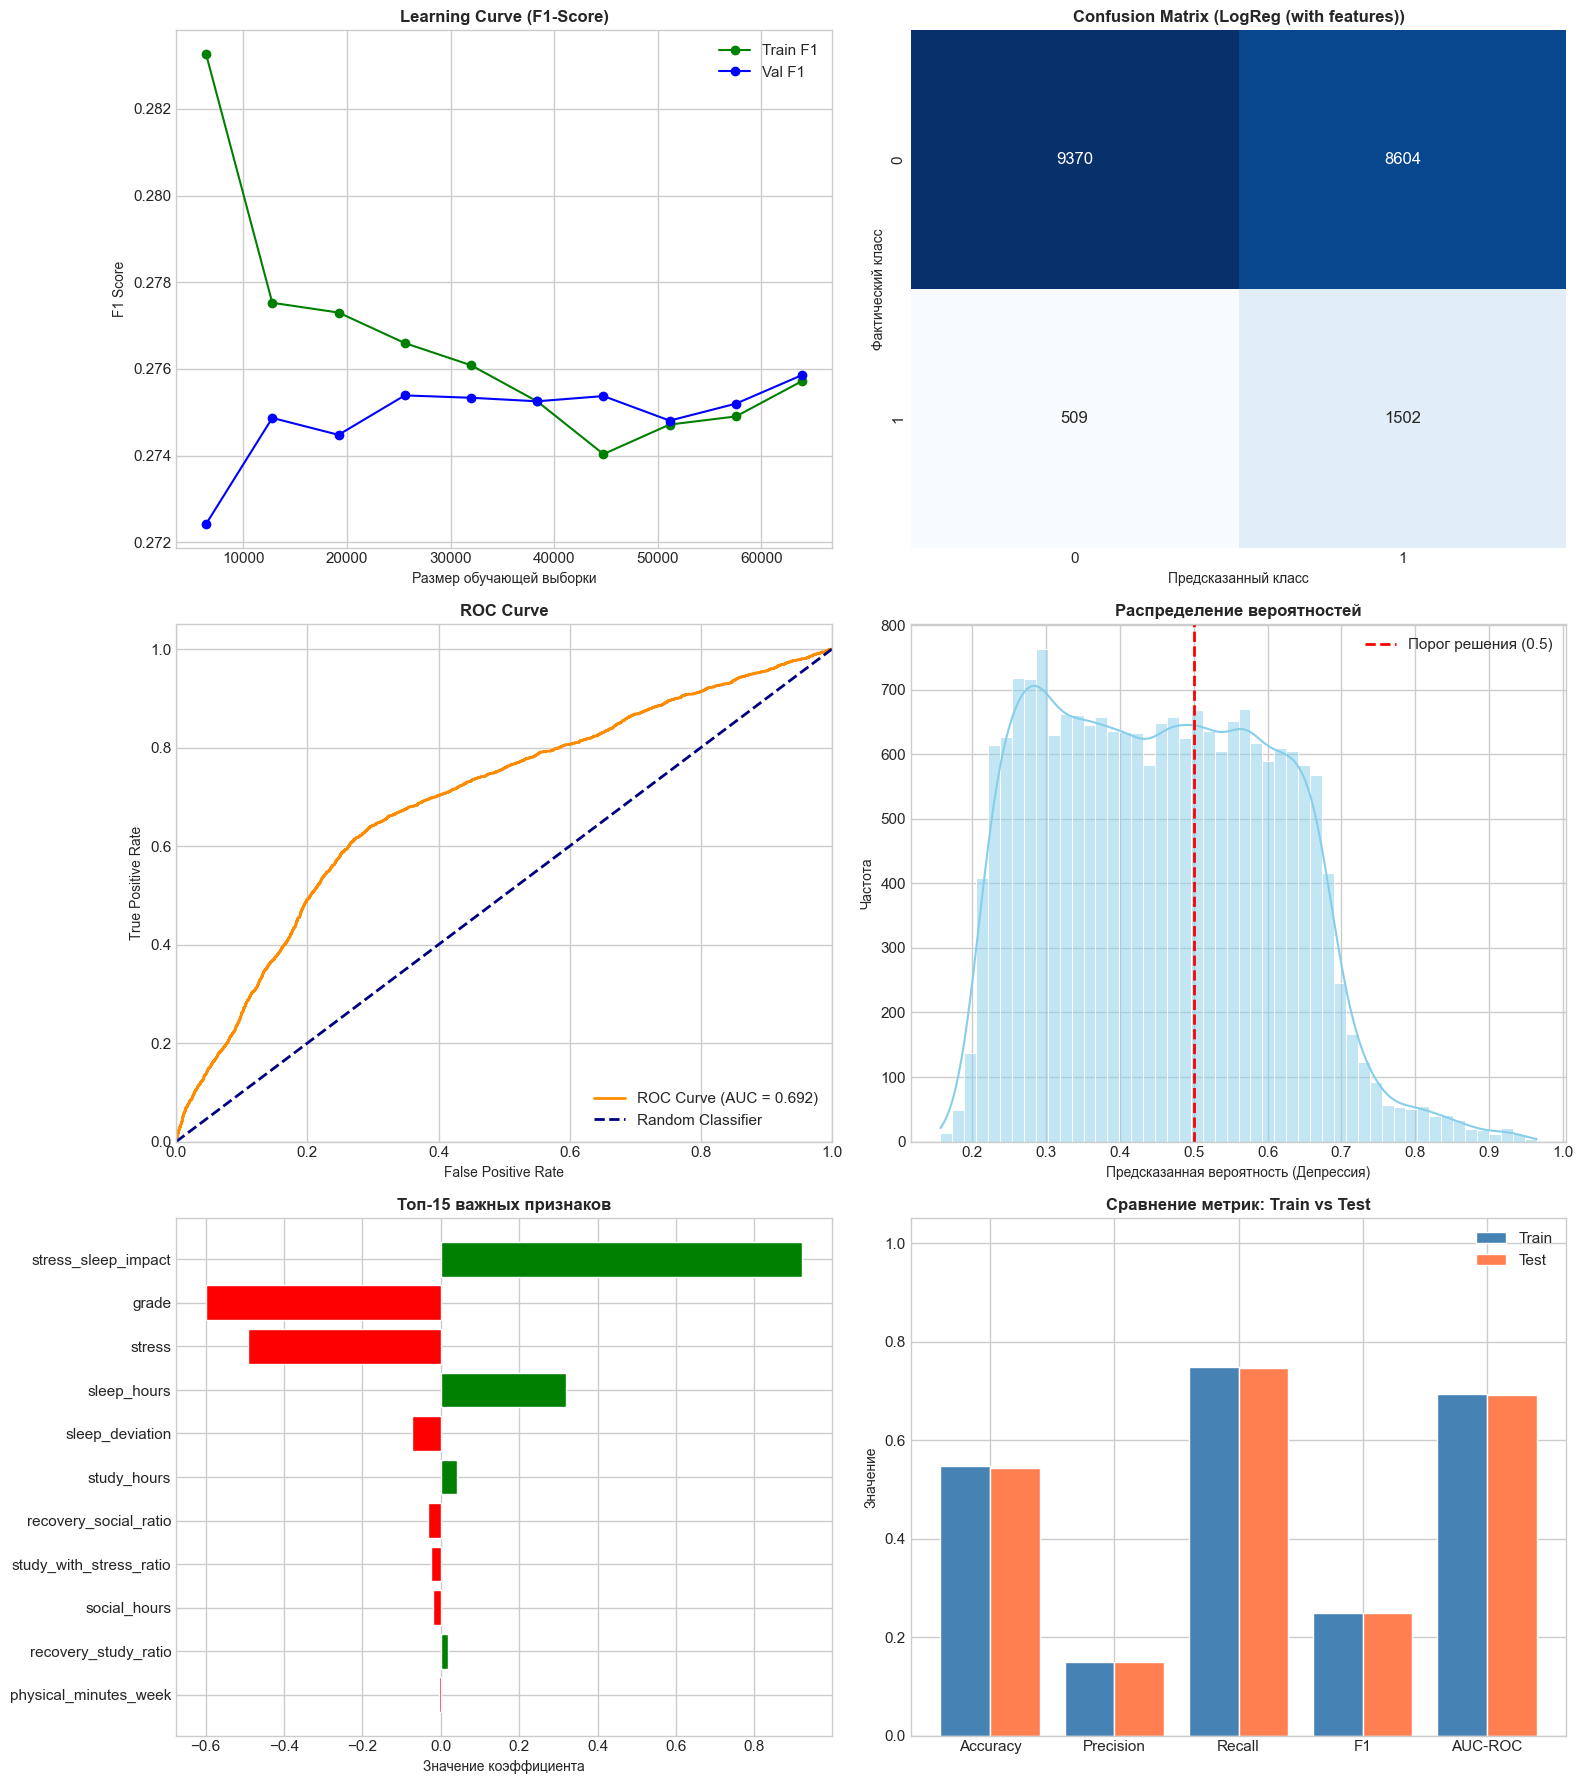

In [2181]:
print("\n=== ТЕСТ С FEATURES ===")

add_custom_features(x_class)
poly_class_metrics = classification_task(x_class, y_class, "LogReg (with features)", use_poly=False,
                                         prev_metrics=base_class_metrics, thrshld=0.45)

###
По идее, если поднимать thrshld, то поднимается Precision, но падает Recall (но нам надо максить Recall)

In [2182]:
print("\n=== ТЕСТ С Thershold == 0.7 ===")
poly_class_metrics_t70 = classification_task(
    x_class,
    y_class,
    "LogReg (with features) (Threshold 0.7)",
    use_poly=True,
    prev_metrics=base_class_metrics,
    thrshld=0.7,
    draw_results=False
)



=== ТЕСТ С Thershold == 0.7 ===

📊 Метрики классификации для LogReg (with features) (Threshold 0.7) (Train):
  Accuracy : 0.8449    – доля правильных ответов (общая точность)
  Precision: 0.2465    – точность (способность отличать этот класс от других)
  Recall   : 0.2629    – полнота (способность находить все объекты этого класса)
  F1       : 0.2544    – гармоническое среднее между точностью и полнотой
  AUC-ROC  : 0.7023    – качество разделения классов моделью (чем выше, тем лучше)

📊 Метрики классификации для LogReg (with features) (Threshold 0.7) (Test):
  Accuracy : 0.8401 [-0.0048 train] (+0.3041 prev)    – доля правильных ответов (общая точность)
  Precision: 0.2293 [-0.0171 train] (+0.0825 prev)    – точность (способность отличать этот класс от других)
  Recall   : 0.2496 [-0.0132 train] (-0.5007 prev)    – полнота (способность находить все объекты этого класса)
  F1       : 0.2390 [-0.0154 train] (-0.0065 prev)    – гармоническое среднее между точностью и полнотой
  AUC-ROC

Т.к. необходимо максить Recall – значение thrshld = 0.45 – одно из самых оптимальных.

**Самые оптимальные результаты показывает модель с Features и 0.45 – далее будем использовать его.**

# 4. SGDClassifier
> Здесь я понял, что нужно было использовать SGDClassifier, для поддержки эпох......

In [2183]:
from sklearn.utils import compute_class_weight
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss


def sgq_task(x, y, lr=0.01, epochs=100, thrshld=0.5, use_poly=False, prev_metrics=None,
             draw_results=True):
    x_train, x_test, y_train, y_test = train_test_split(
        x, y.values, test_size=0.2, random_state=42, stratify=y
    )

    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    class_weights_dict = dict(zip(classes, weights))

    feature_names = x.columns
    if use_poly:
        poly = PolynomialFeatures(degree=2, include_bias=False)
        x_train = poly.fit_transform(x_train)
        x_test = poly.transform(x_test)
        feature_names = poly.get_feature_names_out(x.columns)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(x_train)
    X_test_scaled = scaler.transform(x_test)

    model = SGDClassifier(
        loss='log_loss',
        learning_rate='constant',
        eta0=lr,
        penalty='l2',
        alpha=0.01,
        class_weight=class_weights_dict,
        warm_start=True,
        random_state=42
    )

    train_losses, test_losses = [], []
    classes = np.unique(y_train)

    for epoch in range(epochs):
        model.partial_fit(X_train_scaled, y_train, classes=classes)
        train_proba = model.predict_proba(X_train_scaled)
        test_proba = model.predict_proba(X_test_scaled)

        train_losses.append(log_loss(y_train, train_proba))
        test_losses.append(log_loss(y_test, test_proba))

    y_train_proba = model.predict_proba(X_train_scaled)[:, 1]
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

    y_train_pred = (y_train_proba >= thrshld).astype(int)
    y_test_pred = (y_test_proba >= thrshld).astype(int)

    train_m = evaluate_classification(
        y_train, y_train_pred, y_train_proba, f"SGD Train (LR={lr})",
        feature_names, model.coef_
    )
    test_m = evaluate_classification(
        y_test, y_test_pred, y_test_proba, f"SGD Test (LR={lr})",
        feature_names, model.coef_, prev_metrics=prev_metrics, prev_train=train_m
    )

    # График сходимости
    plt.figure(figsize=(12, 4))
    plt.plot(train_losses, label='Train Loss', color='steelblue', lw=2)
    plt.plot(test_losses, label='Test Loss', color='coral', lw=2, linestyle='--')
    plt.title(f'Сходимость Log Loss (LR={lr}, Epochs={epochs})', fontweight='bold')
    plt.xlabel('Эпоха')
    plt.ylabel('Log Loss')
    plt.legend()
    plt.show()

    print(f"\n🔍 Диагностика Логистической Регрессии (SGD):")
    print(f"  Количество эпох: {epochs}")
    print(f"  Learning Rate:   {lr}")
    print(f"  Регуляризация:   {model.penalty} (alpha={model.alpha})")
    print(f"  Initial Loss:    {train_losses[0]:.4f}")
    print(f"  Final Loss:      {train_losses[-1]:.4f}")

    # Проверка сходимости
    loss_reduction = (train_losses[0] - train_losses[-1]) / train_losses[0] * 100
    if loss_reduction > 50:
        print(f"✅ Хорошая сходимость: Loss снизился на {loss_reduction:.1f}%")
    elif loss_reduction > 10:
        print(f"⚠️ Умеренная сходимость: Loss снизился на {loss_reduction:.1f}%")
    else:
        print(f"⚠️ Плохая сходимость: Loss снизился только на {loss_reduction:.1f}%")

    # Проверка на переобучение
    acc_diff = train_m['Accuracy'] - test_m['Accuracy']
    if acc_diff > 0.1:
        print(f"⚠️ Возможное переобучение!")
    elif acc_diff < -0.05:
        print(f"⚠️ Необычная ситуация: тест лучше трейна. Проверьте разделение данных.")
    else:
        print(f"✅ Модель обобщает данные адекватно")

    if draw_results:
        draw_classification_results(
            model, X_train_scaled, y_train, y_test,
            y_test_pred, y_test_proba, feature_names, f"SGD LR={lr}", train_m, test_m
        )

    return test_m

> Ниже – попытка вернуть результат полученный с `LogisticRegression`. Вроде получилось _(см. метрики, но графики другие)_\
> А ещё очень медленная сходимость(



📊 Метрики классификации для SGD Train (LR=0.0001):
  Accuracy : 0.5511    – доля правильных ответов (общая точность)
  Precision: 0.1510    – точность (способность отличать этот класс от других)
  Recall   : 0.7484    – полнота (способность находить все объекты этого класса)
  F1       : 0.2513    – гармоническое среднее между точностью и полнотой
  AUC-ROC  : 0.6958    – качество разделения классов моделью (чем выше, тем лучше)

📊 Метрики классификации для SGD Test (LR=0.0001):
  Accuracy : 0.5480 [-0.0030 train] (+0.0040 prev)    – доля правильных ответов (общая точность)
  Precision: 0.1489 [-0.0021 train] (+0.0003 prev)    – точность (способность отличать этот класс от других)
  Recall   : 0.7404 [-0.0080 train] (-0.0065 prev)    – полнота (способность находить все объекты этого класса)
  F1       : 0.2479 [-0.0033 train] (+0.0000 prev)    – гармоническое среднее между точностью и полнотой
  AUC-ROC  : 0.6932 [-0.0026 train] (+0.0010 prev)    – качество разделения классов моделью 

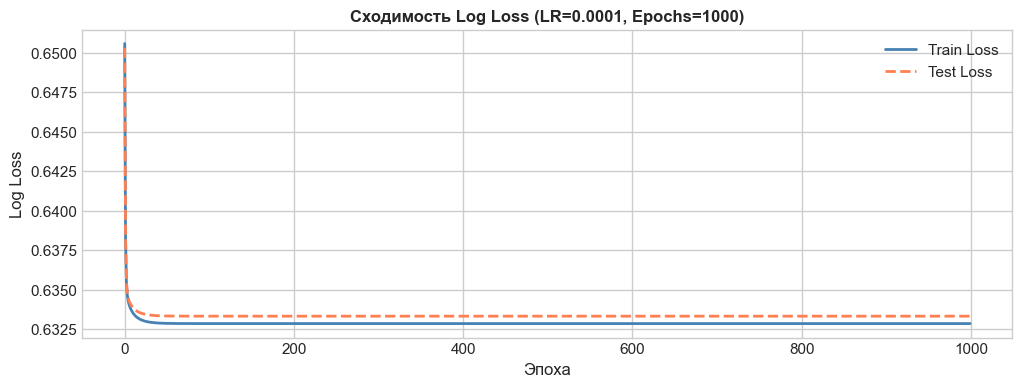


🔍 Диагностика Логистической Регрессии (SGD):
  Количество эпох: 1000
  Learning Rate:   0.0001
  Регуляризация:   l2 (alpha=0.01)
  Initial Loss:    0.6506
  Final Loss:      0.6328
⚠️ Плохая сходимость: Loss снизился только на 2.7%
✅ Модель обобщает данные адекватно


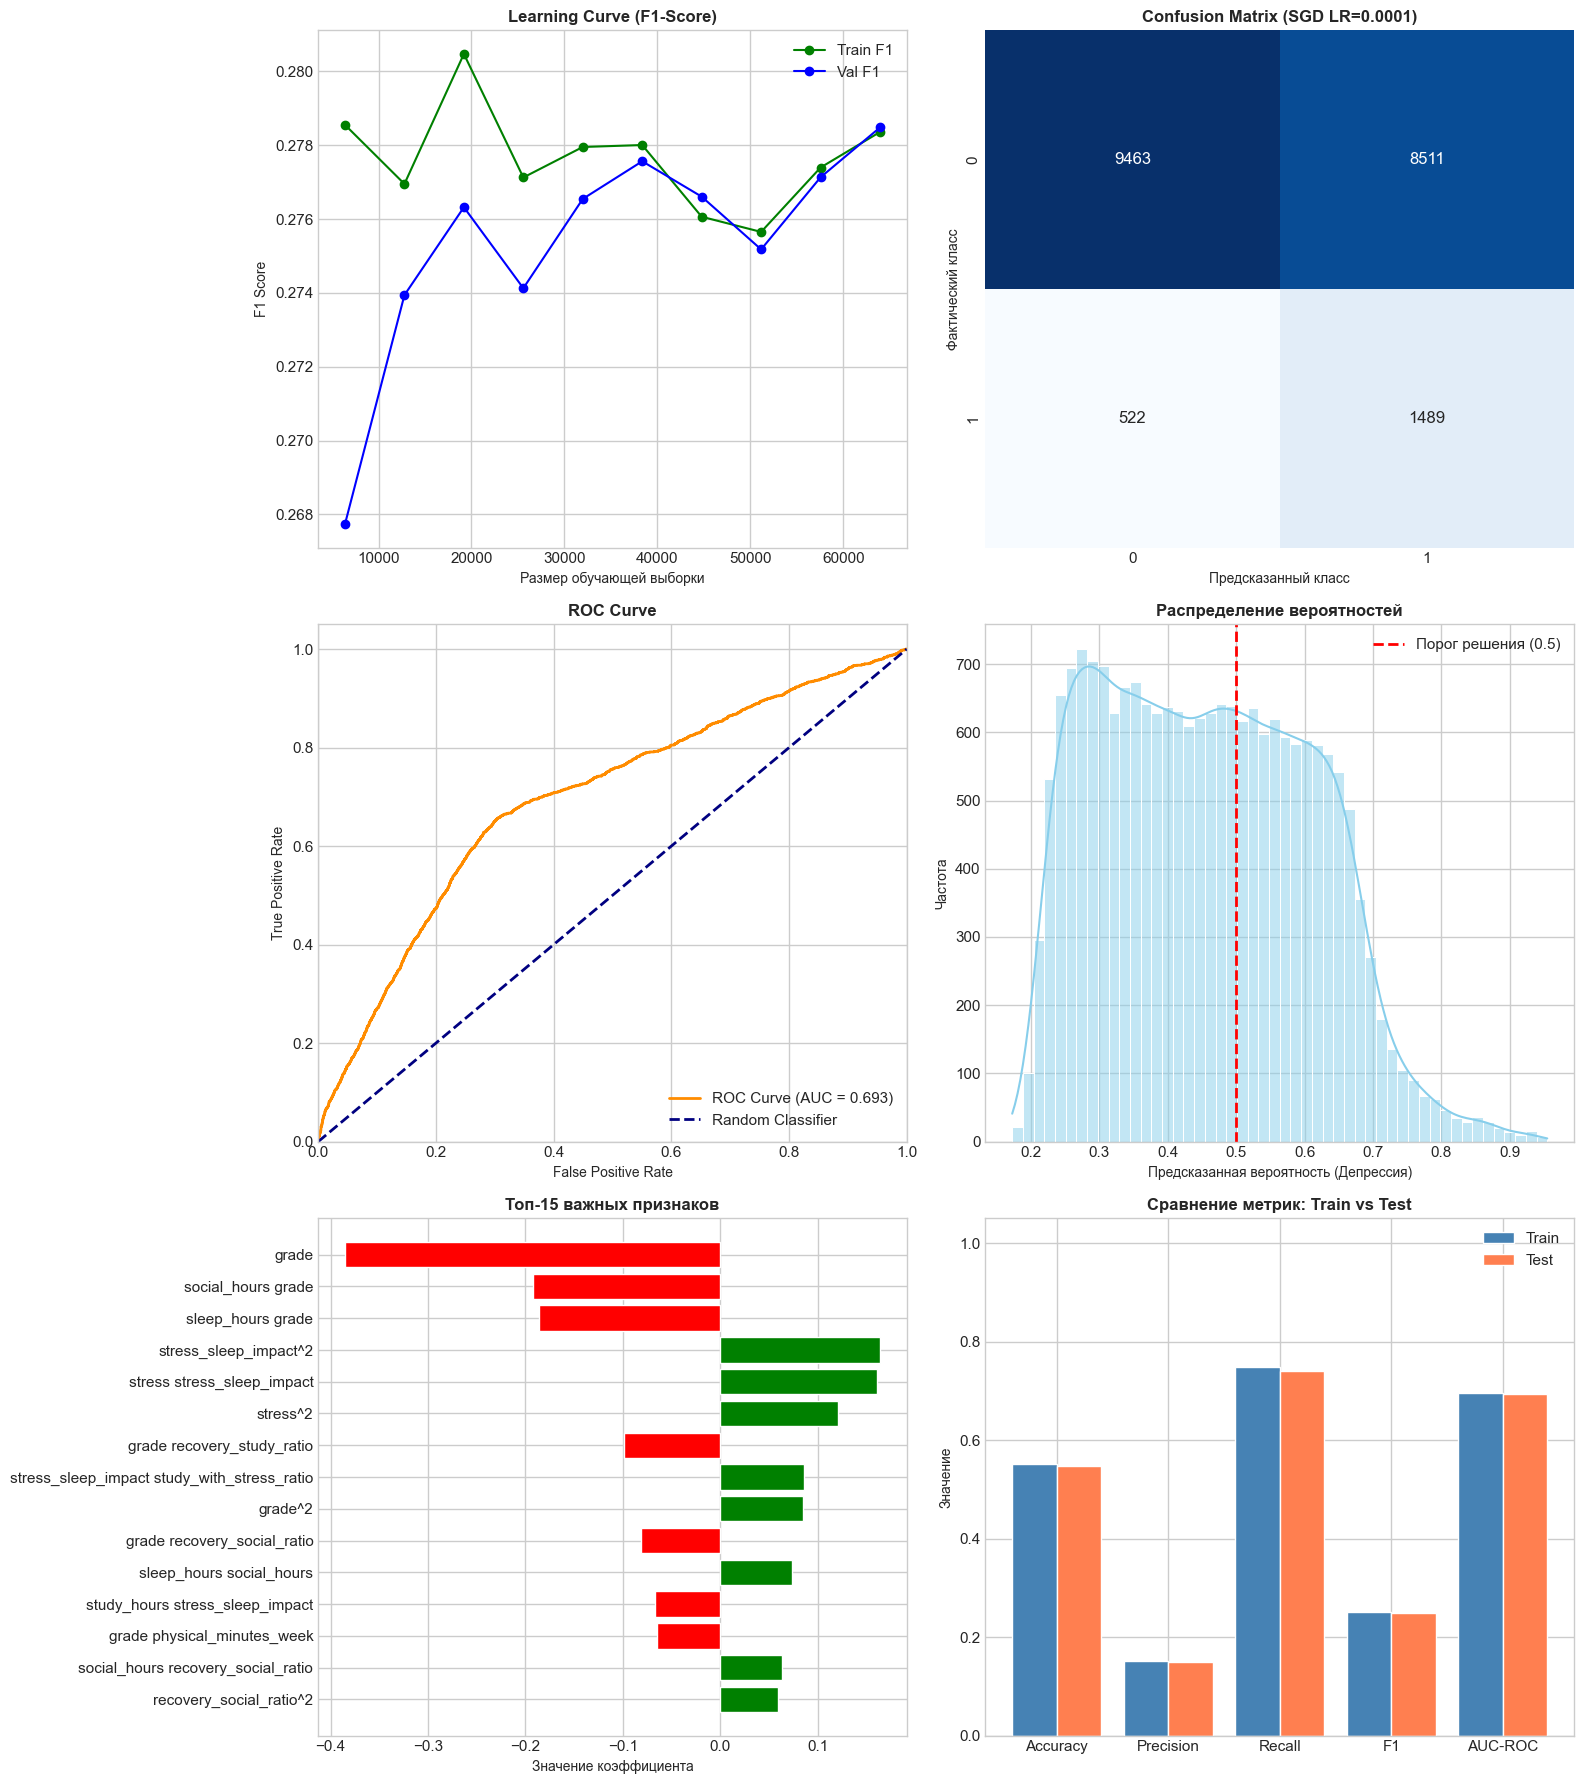

In [2184]:
# Результаты очень схожи с тем, что было до! (какой ценой)
r = sgq_task(
    x_class,
    y_class,
    lr=0.0001,
    epochs=1000,
    thrshld=0.45,
    use_poly=True,
    prev_metrics=poly_class_metrics
)

# 4.1. Эксперименты со значением шага и числом эпох


📊 Метрики классификации для SGD Train (LR=0.0001):
  Accuracy : 0.5511    – доля правильных ответов (общая точность)
  Precision: 0.1510    – точность (способность отличать этот класс от других)
  Recall   : 0.7484    – полнота (способность находить все объекты этого класса)
  F1       : 0.2513    – гармоническое среднее между точностью и полнотой
  AUC-ROC  : 0.6958    – качество разделения классов моделью (чем выше, тем лучше)

📊 Метрики классификации для SGD Test (LR=0.0001):
  Accuracy : 0.5480 [-0.0030 train] (0.0000 prev)    – доля правильных ответов (общая точность)
  Precision: 0.1489 [-0.0021 train] (0.0000 prev)    – точность (способность отличать этот класс от других)
  Recall   : 0.7404 [-0.0080 train] (0.0000 prev)    – полнота (способность находить все объекты этого класса)
  F1       : 0.2479 [-0.0033 train] (0.0000 prev)    – гармоническое среднее между точностью и полнотой
  AUC-ROC  : 0.6932 [-0.0026 train] (0.0000 prev)    – качество разделения классов моделью (чем 

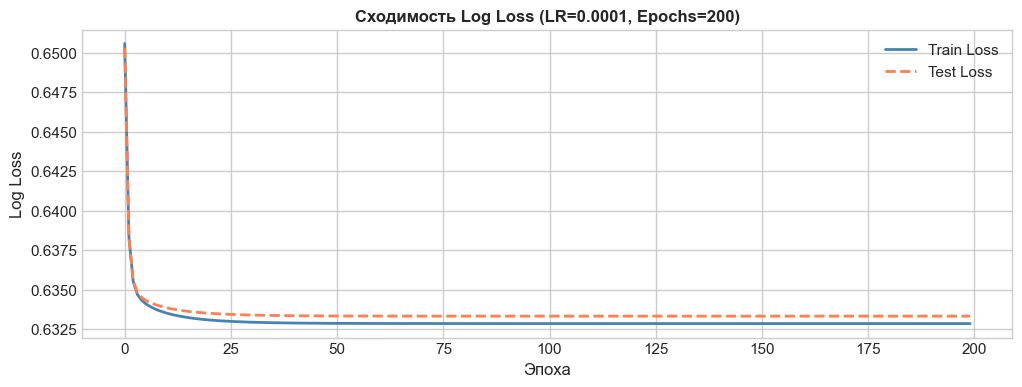


🔍 Диагностика Логистической Регрессии (SGD):
  Количество эпох: 200
  Learning Rate:   0.0001
  Регуляризация:   l2 (alpha=0.01)
  Initial Loss:    0.6506
  Final Loss:      0.6328
⚠️ Плохая сходимость: Loss снизился только на 2.7%
✅ Модель обобщает данные адекватно
------------------------------------------------------------


📊 Метрики классификации для SGD Train (LR=0.05):
  Accuracy : 0.6364    – доля правильных ответов (общая точность)
  Precision: 0.1419    – точность (способность отличать этот класс от других)
  Recall   : 0.5178    – полнота (способность находить все объекты этого класса)
  F1       : 0.2228    – гармоническое среднее между точностью и полнотой
  AUC-ROC  : 0.6202    – качество разделения классов моделью (чем выше, тем лучше)

📊 Метрики классификации для SGD Test (LR=0.05):
  Accuracy : 0.6352 [-0.0012 train] (+0.0872 prev)    – доля правильных ответов (общая точность)
  Precision: 0.1406 [-0.0013 train] (-0.0083 prev)    – точность (способность отличать этот 

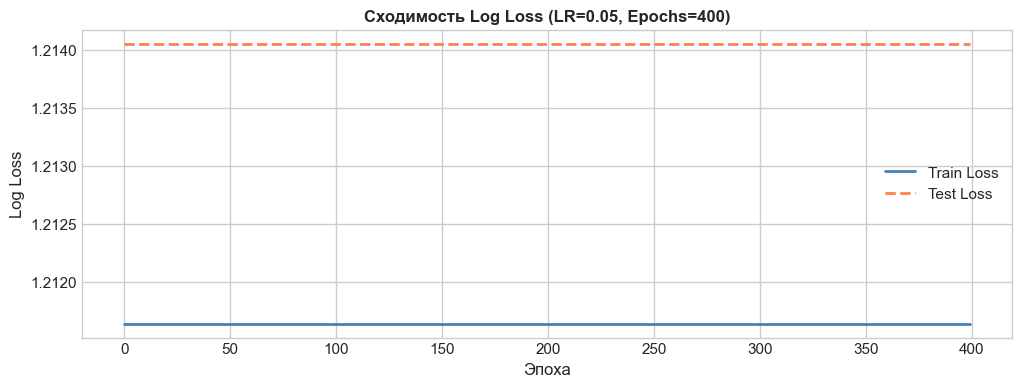


🔍 Диагностика Логистической Регрессии (SGD):
  Количество эпох: 400
  Learning Rate:   0.05
  Регуляризация:   l2 (alpha=0.01)
  Initial Loss:    1.2116
  Final Loss:      1.2116
⚠️ Плохая сходимость: Loss снизился только на 0.0%
✅ Модель обобщает данные адекватно
------------------------------------------------------------


📊 Метрики классификации для SGD Train (LR=0.8):
  Accuracy : 0.7069    – доля правильных ответов (общая точность)
  Precision: 0.1281    – точность (способность отличать этот класс от других)
  Recall   : 0.3295    – полнота (способность находить все объекты этого класса)
  F1       : 0.1845    – гармоническое среднее между точностью и полнотой
  AUC-ROC  : 0.5678    – качество разделения классов моделью (чем выше, тем лучше)

📊 Метрики классификации для SGD Test (LR=0.8):
  Accuracy : 0.7023 [-0.0046 train] (+0.0671 prev)    – доля правильных ответов (общая точность)
  Precision: 0.1268 [-0.0013 train] (-0.0138 prev)    – точность (способность отличать этот клас

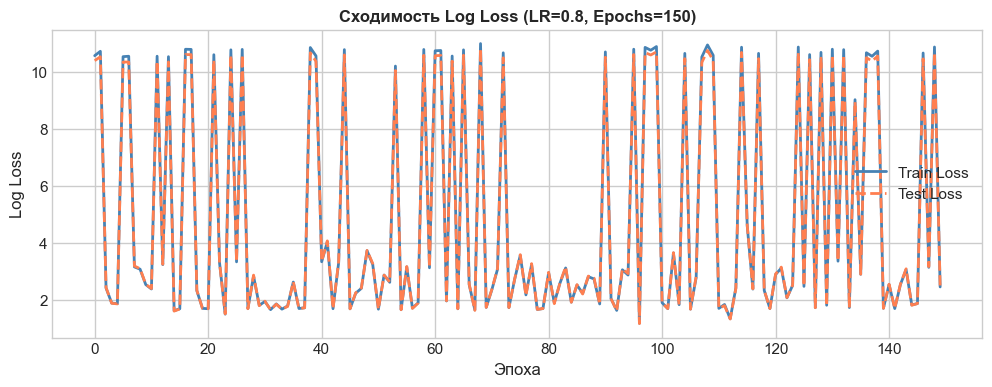


🔍 Диагностика Логистической Регрессии (SGD):
  Количество эпох: 150
  Learning Rate:   0.8
  Регуляризация:   l2 (alpha=0.01)
  Initial Loss:    10.5603
  Final Loss:      2.4548
✅ Хорошая сходимость: Loss снизился на 76.8%
✅ Модель обобщает данные адекватно
------------------------------------------------------------



In [2185]:
should_print_weights = False

experiments = [
    {
        "lr": 0.0001,
        "epochs": 200
    },
    {
        "lr": 0.05,
        "epochs": 400
    },
    {
        "lr": 0.8,
        "epochs": 150,
    }
]

for exp in experiments:
    r = sgq_task(
        x_class,
        y_class,
        lr=exp['lr'],
        epochs=exp['epochs'],
        thrshld=0.45,
        use_poly=True,
        prev_metrics=r,
        draw_results=False
    )

    print("-" * 60, end="\n\n")


# 5. Вывод
Вывод смотрите в [README](./README.md)

**Лучшая модель для классификации** – `LogisticRegression` или самый первый вариант SGD, т.к. они показали лучший результат

# 5. Вывод
Вывод смотрите в [README](./README.md)